# **Deliverable 3: Ultrasound Physics & Imaging**

---

## Overview

This deliverable covers key concepts from **Lectures 19–24** (Weeks 8–9) of the course. You will explore the complete physics foundation underlying modern ultrasound imaging systems, from fundamental acoustic wave behavior through to clinical image formation and artifact management. Your work will integrate theoretical understanding with computational simulations and experimental design problems.

### Learning Outcomes:

Upon successful completion, you will be able to:
1. **Analyze** acoustic propagation through multi-layer tissue models to predict imaging penetration
2. **Design** ultrasound transducer systems with optimized beam characteristics for specific clinical applications
3. **Implement** ultrasound image reconstruction algorithms from simulated echo data
4. **Evaluate** Doppler measurement feasibility for given tissue depths and velocity ranges
5. **Identify and mitigate** artifacts in ultrasound images through understanding of physics mechanisms
6. **Compare and select** ultrasound imaging modes and parameters for clinical scenarios


---

# Part 1: Acoustic Physics & Tissue Interactions

## Key Concepts

**Impedance & Reflection:** Determines how much sound bounces at tissue boundaries
- Z = ρc (impedance in MRayl) — larger impedance mismatch → stronger reflection
- R = (Z₂ − Z₁)/(Z₂ + Z₁) (pressure reflection coefficient)
- R_I = R² (intensity reflection) — fraction of acoustic energy reflected
- T_I = 4Z₁Z₂/(Z₁+Z₂)² (intensity transmission) — fraction that passes through

**Attenuation:** Signal loss as sound travels through tissue due to absorption and scattering
- Loss = α · frequency · distance (higher frequency attenuates faster)
- α ≈ 0.5–0.8 dB/(cm·MHz) in soft tissue
- Round-trip loss: multiply distance by 2 (sound goes down and back up)
- Total loss in dB = 20·log₁₀(transmitted amplitude / received amplitude)

**Wavelength & Frequency:** Trade-off between resolution and penetration
- λ = c / f (c = 1540 m/s in soft tissue)
- Higher frequency f: shorter wavelength → better resolution but greater attenuation → shallower penetration
- Lower frequency f: longer wavelength → worse resolution but less attenuation → better penetration

## 1.1 Acoustic Impedance & Reflection Analysis

Acoustic impedance, Z = ρc, is the fundamental property determining how sound reflects at tissue boundaries. Ultrasound images are primarily formed from echoes at impedance boundaries.

### **Questions 1**
You are designing an ultrasound probe for cardiac imaging. The probe needs good acoustic coupling between the transducer (Z ≈ 25 MRayl) and skin (Z ≈ 1.54 MRayl). 
- a) Calculate the pressure reflection coefficient at the transducer-skin interface **without coupling gel**. What percentage of energy is lost to reflection (intensity)?
- b) Explain why coupling gel (Z ≈ 1.5 MRayl) improves transmission. Calculate the improvement in transmitted intensity.
- c) Why must matching layers be exactly λ/4 thick to optimally reduce reflections? (Hint: Consider wave interference.)

### **Answers for Q1**

a) 
Without coupling gel but directly contact (No air gap)

R = (1.54 - 25)/(1.54 + 25) = −0.8839

The intensity reflection coefficient is (-0.8839)^2 = 0.7813, meaning 78.13% of energy is lost.

Without coupling gel and with air gap (Z air = 0.0004 MRayl)

R^2 = (0.0004 - 25)^2/(0.0004 + 25)^2 ≈ 100%, meaning nearly 100% of energe is lost.
___________________________
b) Transducer - Coupling gel

R = (1.5 - 25)/(1.5 + 25) = -0.887

Energy loss: (-0.887)^2 % = 78.7%

T = 1 - 78.7% = 21.3%

Gel - Skin

T =1 - (1.54 - 1.5)^2/(1.54 + 1.5)^2 = 99.98%

Gel displaces the air, bridging the impedance gap. With gel, the transmission improves from almost 0% to approximately 21.3%.
______________________________
c) A λ/4 thickness ensures that the sound wave reflected from the back of the matching layer travels an extra λ/2 round-trip distance compared to the wave reflected from the front. This causes destructive interference between the reflections, canceling them out and maximizing transmission.

### **Questions 2**
In abdominal imaging, you encounter three successive tissue boundaries:
1. Skin (ρ = 1100 kg/m³, c = 1700 m/s) → Fat (ρ = 900 kg/m³, c = 1450 m/s)
2. Fat → Muscle (ρ = 1050 kg/m³, c = 1580 m/s)
3. Muscle → Bone cortical (ρ = 1850 kg/m³, c = 3500 m/s)

- a) Calculate Z for each tissue
- b) Calculate reflection coefficients at each boundary
- c) Rank the boundaries by reflection strength. Which is most problematic for imaging?
- d) Why are cortical bone landmarks often clearly visible as "dark shadows" in ultrasound?

### **Answers for Q2**
a) Z=pc

Skin: 1100 * 1700 = 1.87 MRayl

Fat: 900 * 1450 = 1.31 MRayl

Muscle: 1050 * 1580 = 1.66 MRayl

Bone: 1850 * 3500 = 6.48 MRayl
_______________________________
b) Skin - Fat

R1 = (1.31 - 1.87)/(1.31 + 1.87) = -0.176

Fat - Muscle

R2 = (1.66 - 1.31)/(1.66 + 1.31) = 0.118

Muscle - Bone cortical

R3 = (6.48 - 1.66)/(6.48 + 1.66) = 0.592
_____________________________
c) Muscle - Bone: 0.592 (highest)(Most problematic)

Because of the massive impedance mismatch, about 35%(0.592^2) of the sound energy is reflected back at this single interface. This prevents the ultrasound from penetrating deeper to see structures behind the bone.

Skin - Fat: 0.176

Fat - Muscle: 0.118 (Lowest)
_______________________________
d) Because of the massive reflection at the tissue-bone interface combined with heavy attenuation within the dense bone itself. Very little sound reaches structures behind the bone, creating an anechoic shadow.


## 1.2 Multi-Layer Tissue Transmission Model

Ultrasound must penetrate through multiple tissue layers to reach target organs. Both reflection losses at each interface and attenuation within each tissue layer reduce the overall signal strength. This analysis predicts whether adequate signal will return for imaging.

### **Coding Exercise 1**

Implement a function to calculate total round-trip transmission through multiple tissue layers, accounting for:
1. **Interface losses:** Reflection loss at each boundary between different tissues
2. **Attenuation losses:** Frequency-dependent signal loss as sound propagates through each layer (round-trip)

Return the overall transmission loss in dB and identify the dominating loss mechanism(s).

In [1]:
import math

def calculate_transmission_model(f_MHz):

# TODO: Define tissue properties (impedance, attenuation coefficient, thickness)
# ...
    layers =[
        {"name": "Skin",   "Z": 1.87,  "alpha": 0.5, "d": 0.2},
        {"name": "Fat",    "Z": 1.31, "alpha": 0.5, "d": 2.0},
        {"name": "Muscle", "Z": 1.66, "alpha": 0.5, "d": 3.0}
    ]

# TODO: Calculate reflection losses at each interface
# ...
    interface_loss_dB = 0.0
    for i in range(len(layers) - 1):
        Z1 = layers[i]["Z"]
        Z2 = layers[i+1]["Z"]
        R_I = ((Z2 - Z1) / (Z2 + Z1)) ** 2
        T_I = 1 - R_I
        interface_loss_dB += -20 * math.log10(T_I)

# TODO: Report total loss in dB and identify dominant mechanism
# ...
    attenuation_loss_dB = 0.0
    for layer in layers:
        attenuation_loss_dB += 2 * layer["alpha"] * f_MHz * layer["d"]

# TODO: Calculate attenuation losses through each layer (round-trip)
# ...
    total_loss_dB = interface_loss_dB + attenuation_loss_dB
    dominant = "Attenuation" if attenuation_loss_dB > interface_loss_dB else "Reflection"
    
    print(f"Total Loss: {total_loss_dB:.2f} dB")
    print(f"Dominant Mechanism: {dominant}")
    
    return total_loss_dB, dominant

## 1.3 Clinical Penetration Analysis

### **Questions 3**

You are choosing the operating frequency for obstetric ultrasound in a pregnant patient at different gestational ages.
- a) **First Trimester (up to 3 cm depth through maternal tissue):** Compare 10 MHz vs. 5 MHz
  - Calculate expected round-trip loss through skin (0.2 cm) + adipose (2 cm) at both frequencies
  - Which frequency is better and why?

- b) **Third Trimester (6–8 cm depth):** Should you switch to a lower frequency? Estimate the penetration limit at 3.5 MHz (typical for this scenario).

### **Answers for Q3**

a) One-way depth: 2.2 cm

alpha: 0.5 dB/(cm.MHz)

10 MHz Loss: 2 * 2.2 * 0.5 * 10 = 22 dB

10 MHz Loss: 2 * 2.2 * 0.5 * 5 = 11 dB

Although the loss of 10 MHz is higher than that of 5 MHz, the dynamic range of ultrasound instruments can handle this level of attenuation. Since the fetus is very small in early pregnancy, we need higher axial resolution to observe the details of embryonic development, and higher frequencies provide better resolution.
_________________________________
b) Yes, deep imaging requires a lower frequency to prevent total signal loss. Assuming a typical system dynamic range limit of 60 dB:

60 dB = 2 * dmax * 0.5 * 3.5 MHz 

dmax = 17.1 cm


### **Questions 4**

Abdominal imaging in an obese patient requires imaging through 5 cm of additional adipose tissue. Assuming a 2–5 MHz transducer:
- a) How much additional loss (in dB) occurs due to the extra fat layer?
- b) What compensatory adjustments to transducer power might be necessary?
- c) Why might harmonic imaging be attractive here despite resolution trade-offs?

### **Answers for Q4**

a) The extra loss is 2 * 5cm * 0.5 * f = 5f dB
For a 2-5 MHz transducer, this adds between 10 dB - 25 dB of additional round-trip loss.
______________________
b) The sonographer needs to adjust the TGC sliders to amplify deeper echoes, and may also need to increase output power while adhering to ALARA principles.
_________________________
c) Tissue Harmonic Imaging receives signals at 2f0. Because harmonics build up deep within the tissue, it is absent in the near field. This cuts through and reduces the intense near-field clutter/reverberation artifacts caused by the thick adipose wall, producing a cleaner image with better contrast.

---

# Part 2: Transducers & Beam Forming

## Key Concepts
**Wavelength & Element Spacing:** Fundamental limitation for phased arrays
- λ = c / f (c = 1540 m/s)
- Element spacing s ≤ λ/2 — prevents unwanted secondary lobes (grating lobes)

**Beam Geometry:** How the acoustic beam spreads and focuses
- Near-field length: N = D²/(4λ) where D = aperture diameter — distance from transducer to focal point
- Far-field divergence angle: θ ≈ λ/D (radians) — beam spreads beyond focal point
- Lateral resolution at focal depth: ≈ λ·z/D (z = focal depth) — tightest beam at focal point

**Axial Resolution:** Along the beam direction, determined by pulse length
- δz = (c · τ) / 2 where τ = pulse duration — shorter pulses give better resolution
- Trade-off: shorter pulses require wider bandwidth, which reduces signal-to-noise ratio

**Focal Zone:** Where beam is narrowest and lateral resolution is best
- Lateral resolution is excellent at focal depth, degrades in near field and far field
- Multiple focal zones (electronic or mechanical) improve coverage but reduce frame rate

## 2.1 Transducer Design & Near-Field Analysis

### **Questions 5**

You are designing a linear array transducer for abdominal imaging. Frequency: 5 MHz, Desired penetration: 15 cm, Focal zone: ~4 cm
- a) Calculate the wavelength in soft tissue at 5 MHz (c = 1540 m/s)
- b) What is the minimum element spacing to avoid grating lobes (phased array constraint)?
- c) To achieve 4 cm focal zone, what aperture diameter (number of active elements) is required? (Hint: N = D²/(4λ))
- d) Compare a 64-element vs 128-element array: which has better lateral resolution and why?

### **Answers for Q5**

a) λ = c/f = 1540 m/s / 5 MHz = 0.000308 m = 0.308 mm

b) Spacing s ≤ λ/2 = 0.308 mm / 2 = 0.154 mm

c) N = 4 cm = 40 mm

40 = D^2 / (4 * 0.308) 

D = 7.02 mm

Number of elements: 7.02 / 0.154 = 46

d) The 128-element array has better lateral resolution. A higher number of elements increases the aperture size D. According to λ * z/D, a large D creates a narrower beam width at the focal point, hence a finer/better resolution.

### **Questions 6**

A 7.5 MHz transducer for cardiac imaging through intercostal spaces has a diameter of 12 mm.
- a) Calculate the near-field length
- b) Calculate the far-field divergence angle
- c) Can this transducer achieve useful resolution at 10 cm depth (typical mitral valve location)? Why or why not?

### **Answers for Q6**

a) For 7.5 MHz, λ = 1540 / 7.5 MHz = 0.2053 mm

N = D^2 / 4λ = 12^2 / (4 * 0.2053) = 175.3 mm = 17.53 cm

b) θ = λ / D = 0.2053 / 12 = 0.0171 radians

c) Although calculations show that 10 cm is still within the near-field range, the frequency of 7.5 MHz is too high. High-frequency sound waves attenuate very rapidly in tissue. In adult cardiac imaging, a depth of 10 cm typically requires a 2–5 MHz probe to achieve sufficient penetration. After a 20 cm round-trip at 7.5 MHz, almost all the energy is lost, resulting in a very dark image with a very low signal-to-noise ratio.

A 7.5 MHz probe is typically used for superficial organs such as the thyroid or carotid artery, at depths of about 1–4 cm. For imaging deep cardiac structures (such as the mitral valve), the frequency must be reduced to gain sufficient penetration.

## 2.2 Electronic Beam Steering & Focusing

### **Coding Exercise 2**

Implement a phased array beam-forming simulator. Calculate the time delays required to:
1. **Focus the transmit beam** at a specified focal depth
2. **Steer the beam** to a specified angle
3. **Simulate receive beam forming** by applying delays to received signals

Visualize the resulting beam pattern and assess the impact of different arrays (64 vs 128 elements) and frequencies.

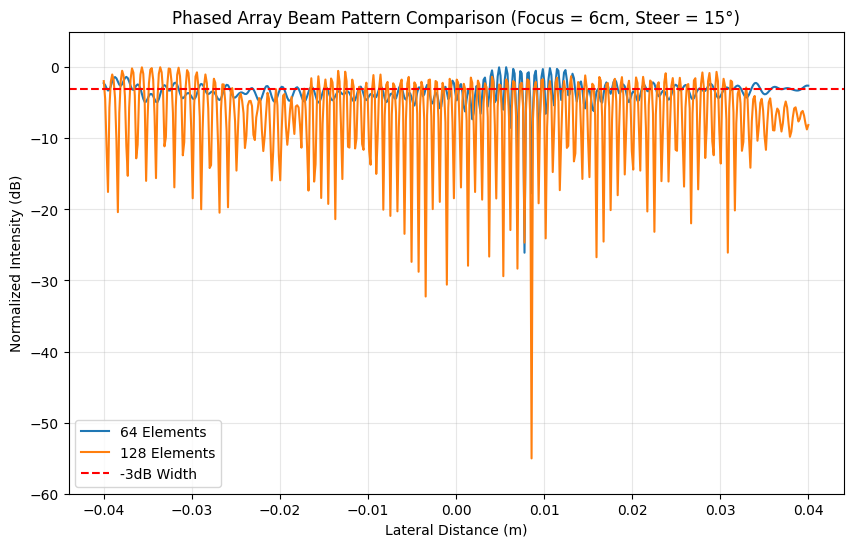

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: Calculate wavelength and set up array geometry
# ...

c = 1540.0
f = 5e6
wavelength = c / f
element_spacing_mm = 0.4
pitch = element_spacing_mm / 1000.0
zf = 0.06
steer_angle = np.radians(15)

# TODO: Calculate transmit delays for focusing at specified depth
# ...

def get_delays(N):
    x = (np.arange(N) - (N - 1) / 2) * pitch
    dist = np.sqrt(x**2 + zf**2)
    focus_delays = (np.max(dist) - dist) / c
    
# TODO: Calculate transmit delays for beam steering at specified angle
    # Logic: delay = (x * sin(theta)) / c
    steer_delays = (x * np.sin(steer_angle)) / c
    steer_delays -= np.min(steer_delays)
    return x, focus_delays + steer_delays

# TODO: Simulate and visualize beam patterns
# ...

def simulate(N):
    x_elements, total_delays = get_delays(N)
    px = np.linspace(-0.04, 0.04, 500)
    pressure = np.zeros_like(px, dtype=complex)
    
    for i in range(N):
        r = np.sqrt((px - x_elements[i])**2 + zf**2)
        # Phase = 2*pi*f * (time_of_flight - electronic_delay)
        phase = 2 * np.pi * f * (r / c - total_delays[i])
        pressure += np.exp(-1j * phase)
        
    intensity_db = 20 * np.log10(np.abs(pressure) / np.max(np.abs(pressure)))
    return px, intensity_db


# TODO: Compare different array configurations (64 vs 128 elements)
# ...

element_spacing_mm = 0.4

px, pattern64 = simulate(64)
_, pattern128 = simulate(128)

plt.figure(figsize=(10, 6))
plt.plot(px, pattern64, label='64 Elements', linewidth=1.5)
plt.plot(px, pattern128, label='128 Elements', linewidth=1.5)
plt.axhline(-3, color='red', linestyle='--', label='-3dB Width')
plt.ylim(-60, 5)
plt.xlabel('Lateral Distance (m)')
plt.ylabel('Normalized Intensity (dB)')
plt.title('Phased Array Beam Pattern Comparison (Focus = 6cm, Steer = 15°)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ...

# TODO: Calculate wavelength and element positions# TODO: Calculate transmit delays for focusing and steering# ...



### **Notes??**
The multiple high peaks are Grating Lobes. They occur because the 0.4 mmspacing exceeds the λ/2 limit (0.154 mm), violating the design constraint for phased arrays??

## 2.3 Lateral Resolution Across Focal Zone

### **Questions 7**

A 5 MHz linear array with 128 elements and 0.4 mm spacing is used for abdominal imaging with an electronic focal depth of 6 cm.
- a) Calculate the lateral resolution at the focal depth
- b) Calculate the lateral resolution at 1 cm (near field) and 15 cm (far field)
- c) Plot lateral resolution vs depth. At what depths does lateral resolution exceed (degrade beyond) 1 mm?
- d) How could you improve lateral resolution at 15 cm depth? What are the trade-offs of each approach?

### **Answers for Q7**
a) λ = c/f = 1540 m/s / 5 MHz = 0.308 mm

D = 128 * 0.4 mm = 51.2 mm

Rlat = 0.308 mm * 60 mm / 51.2 mm = 0.36 mm
______________________
b) At 1cm, near field:

W = D * (1 - z/F) = 51.2 * (1 - 10/60) = 42.7 mm 

At 15 cm, far field:

Rlat = λ * z / D = 0.308 * 150 / 51.2 = 0.90 mm 
__________________________
c) The lateral resolution follows a "V" shape with depth. It is narrowest at the focal point (6 cm), where the numerical value is smallest and the resolution is highest. It degrades in deeper regions due to diffraction.

Set Rlat = 1 mm

1 = 0.308 * z / 51.2 

z = 166mm = 16.6 cm
____________________________
d) To optimize ultrasound resolution, one can increase aperture or frequency, though these lead to bulkier probes or limited penetration. Alternatively, adjusting the focal zone to 15cm sacrifices shallow-tissue clarity, while harmonic imaging refines beam width at the cost of signal strength and processing complexity.


# Part 3: Image Formation & Reconstruction

---

## Key Concepts

**Time-Distance Relationship:** Converting echo timing to depth
- Depth = (c × time) / 2 where time is round-trip, c = 1540 m/s
- Every echo is displayed as a scan line, with brightness (intensity) encoded from the echo amplitude
- Axial resolution limited by pulse duration: δz = (c · τ) / 2 — can't resolve echoes closer than one pulse length apart

**Signal Processing Pipeline:** Sequential steps to convert raw RF data to viewable B-mode image
1. **Envelope Detection:** Extract amplitude envelope from RF signal — removes high-frequency carrier, keeps time-varying amplitude
2. **TGC (Time-Gain Compensation):** Multiply by gain increasing with depth to correct for attenuation losses
3. **Log Compression:** Convert to dB scale — compresses ~100 dB dynamic range to ~50 dB for display
4. **Scan Conversion:** Map from polar (angle, depth) to Cartesian (x, y) coordinates for rectangular display

**Frame Rate Constraint:** Speed at which images update on screen
- Time per scanline ≈ 2·(max depth)/c — limited by sound travel time
- Frame rate = 1 / (time per scan_line × num_scanlines)
- Adding multiple focal zones increases scanline time → reduces frame rate (trade-off for better image quality)

## 3.1 B-Mode Image Formation from Echo Data

### **Questions 8**
In a B-mode ultrasound image, three echoes are detected at times 50 μs, 80 μs, and 150 μs, with amplitudes 60 dB, 40 dB, and 25 dB respectively.
- a) Calculate the depths of the three reflectors (c = 1540 m/s)
- b) If the transducer is operating at 5 MHz with a 2-cycle pulse length, what is the axial resolution?
- c) Can the system resolve the first two echoes, or will they merge? Justify.
- d) Explain why all three echoes must be displayed on a logarithmic (dB) scale rather than linear amplitude.

### **Answers for Q8**

a)

Echo 1 (50 us):

d1 = (1540 * 50 * 10^-6) / 2 = 0.0385 m = 38.5 mm

Echo 2 (80 us):

d2 = (1540 * 80 * 10^-6) / 2 = 0.0616 m = 61.6 mm

Echo 3 (150 us):

d3 = (1540 * 150 * 10^-6) / 2 = 0.1155 m = 115.5 mm
_____________________________________

b)

λ = c / f = 1540 / (5 * 10^6) = 0.000308 m = 0.308 mm

SPL = n * lambda = 2 * 0.308 = 0.616 mm

R_axial = SPL / 2 = 0.616 / 2 = 0.308 mm
_________________________

c) Yes

The distance between the first two reflectors is Delta_d = d2 - d1 = 61.6 - 38.5 = 23.1 mm. Since this distance (23.1 mm) is much larger than the axial resolution (0.308 mm), the two reflectors will appear as distinct objects.
_____________________________

d) Dynamic Range: Ultrasound echoes have a massive range of intensities (often > 100 dB). Strong echoes from bone/tissue interfaces can be millions of times stronger than weak scattering from small structures.
Compression: A linear scale cannot display such a wide range simultaneously, weak signals would be invisible, or strong signals would saturate the screen. The logarithmic scale compresses this dynamic range into a format the human eye and electronic displays can handle.


### **Questions 9**
A linear array acquires 128 scan lines at 50 frames/second. Each scan line goes to 15 cm depth. 
- a) Calculate the time available per scan line for transmit + receive
- b) Is this sufficient for sound to travel to 15 cm and return? (Include time for multiple focal zones.)
- c) If the system uses 2 focal zones instead of 1, how is frame rate affected?
- d) What happens to temporal resolution (ability to detect motion) if you add a second focal zone?

### **Answers for Q9**

a) T_line = 1 / 6400 s = 0.00015625 s = 156.25 us

b) T_needed = 15 cm * 13 us/cm = 195 us

No Since 156.25 us < 195 us, the time is not enough to receive echoes from 15 cm depth at this frame rate.

c) Each focal zone requires a separate pulse-echo sequence for every scan line. Two focal zones means the system must send two pulses per line.

The frame rate will be halved. In this case, it would drop from 50 fps to 25 fps.

d) Temporal resolution decreases. Because the frame rate is lower, the system takes longer to create a single image, making it less capable of accurately tracking fast-moving structures (like heart valves).

## 3.2 Ultrasound Image Reconstruction from Simulated Echo Data

### **Coding Exercise 3**

Implement a B-mode image reconstruction pipeline from simulated RF echo data:

1. **Create synthetic scattering phantom** using point scatterers
2. **Compute echo signals** for each beam direction
3. **Generate RF data** at transducer frequency
4. **Signal Processing:**
   - Envelope detection (analytic signal)
   - Time-gain compensation (TGC)
   - Log compression (dB scaling)
5. **Scan Conversion:** Map polar to Cartesian coordinates
6. **Display and analyze** reconstructed B-mode image

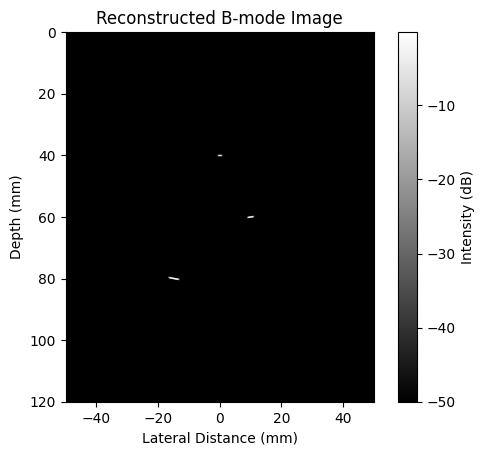

In [11]:
import numpy as np
from scipy.signal import hilbert
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# TODO: Create synthetic scattering phantom using point scatterers
# ...

c = 1540
fs = 40e6
f0 = 5e6
t = np.arange(0, 2e-4, 1/fs)
num_lines = 128
angles = np.linspace(-np.pi/6, np.pi/6, num_lines)
phantom = np.array([[0, 0.04, 1.0], [0.01, 0.06, 0.8], [-0.015, 0.08, 0.5]])

# TODO: Simulate RF echo data for each scanline
# ...

rf_data = np.zeros((num_lines, len(t)))
for i, angle in enumerate(angles):
    for sx, sy, ref in phantom:
        r = np.sqrt(sx**2 + sy**2)
        theta = np.arctan2(sx, sy)
        if np.abs(angle - theta) < 0.02:
            td = 2 * r / c
            pulse = ref * np.exp(-((t - td) * f0)**2) * np.cos(2 * np.pi * f0 * (t - td))
            rf_data[i, :] += pulse

# TODO: Apply envelope detection to extract amplitude from RF signal
# ...

envelope = np.abs(hilbert(rf_data, axis=1))

# TODO: Apply time-gain compensation (TGC)
# ...

depths = (t * c) / 2
alpha = 0.5 * 100 * (f0 / 1e6) 
tgc_gain = np.exp(alpha * depths / 8.686)
tgc_envelope = envelope * tgc_gain


# TODO: Apply log compression (dB scale)
# ...

log_img = 20 * np.log10(tgc_envelope / np.max(tgc_envelope) + 1e-5)
log_img = np.clip(log_img, -50, 0)


# TODO: Perform scan conversion (polar to Cartesian)
# ...

r_grid, theta_grid = np.meshgrid(depths, angles)
x_polar = r_grid * np.sin(theta_grid)
y_polar = r_grid * np.cos(theta_grid)
x_cart = np.linspace(-0.05, 0.05, 400)
y_cart = np.linspace(0, 0.12, 400)
X, Y = np.meshgrid(x_cart, y_cart)
bmode_img = griddata((x_polar.flatten(), y_polar.flatten()), log_img.flatten(), (X, Y), method='linear', fill_value=-50)

# TODO: Display and analyze reconstructed B-mode image
# ...

plt.imshow(bmode_img, extent=[-50, 50, 120, 0], cmap='gray')
plt.title("Reconstructed B-mode Image")
plt.xlabel("Lateral Distance (mm)")
plt.ylabel("Depth (mm)")
plt.colorbar(label="Intensity (dB)")
plt.show()

## 3.3 Shepp-Logan Phantom Reconstruction

### **Coding Exercise 4**

Validate your B-mode reconstruction pipeline from **Coding Exercise 3** by applying it to a **Shepp-Logan digital phantom**. This simulates a more realistic imaging scenario with defined tissue-like features, allowing you to assess how well your algorithm handles anatomically-plausible structures compared to the simple synthetic scatterers in Exercise 3.

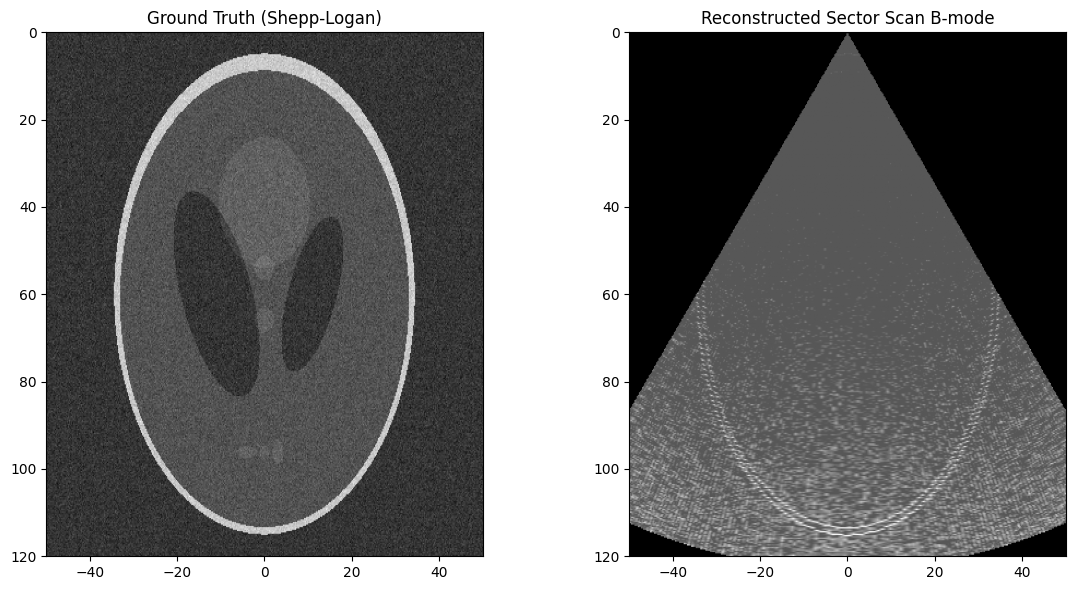

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.interpolate import griddata
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

# TODO: Load Shepp-Logan phantom
# from skimage.data import shepp_logan_phantom
# phantom = shepp_logan_phantom()
# ...

phantom_raw = shepp_logan_phantom()
phantom = resize(phantom_raw, (400, 400))

np.random.seed(42) 
phantom += np.random.normal(0, 0.08, phantom.shape) 

# TODO: Apply your reconstruction pipeline from Exercise 3 to this phantom
# ...

c = 1540
fs = 40e6
f0 = 5e6
num_lines = 128
angles = np.linspace(-np.pi/6, np.pi/6, num_lines)
t = np.arange(0, 1.6e-4, 1/fs)
depths = (t * c) / 2

# Generate pulse
t_pulse = np.arange(-5/f0, 5/f0, 1/fs)
pulse = np.exp(-(t_pulse * f0)**2) * np.cos(2 * np.pi * f0 * t_pulse)

# Polar Simulation (Sector Scan)
polar_data = np.zeros((num_lines, len(t)))
px_indices = np.linspace(-1, 1, 400)
py_indices = np.linspace(0, 1, 400)

for i, angle in enumerate(angles):
    # Calculate sampling path in Cartesian coordinates
    path_x = depths * np.sin(angle)
    path_y = depths * np.cos(angle)
    
    # Map path to phantom pixel coordinates
    ix = np.interp(path_x, [-0.05, 0.05], [0, 399]).astype(int)
    iy = np.interp(path_y, [0, 0.12], [0, 399]).astype(int)
    
    # Keep path within phantom bounds
    mask = (ix >= 0) & (ix < 400) & (iy >= 0) & (iy < 400)
    line_reflectivity = np.zeros(len(t))
    line_reflectivity[mask] = phantom[iy[mask], ix[mask]]
    
    # Convolve with pulse to create RF data
    polar_data[i, :] = np.convolve(line_reflectivity, pulse, mode='same')

# 1. Envelope Detection
envelope = np.abs(hilbert(polar_data, axis=1))

# 2. TGC (Time-Gain Compensation)
alpha = 0.5 * 100 * (f0 / 1e6)
tgc_gain = np.exp(alpha * depths / 8.686)
tgc_envelope = envelope * tgc_gain

# 3. Log Compression (dB scale)
log_img = 20 * np.log10(tgc_envelope / (np.max(tgc_envelope) + 1e-9) + 1e-5)
log_img = np.clip(log_img, -30, 0)

r_grid, theta_grid = np.meshgrid(depths, angles)
x_polar = r_grid * np.sin(theta_grid)
y_polar = r_grid * np.cos(theta_grid)

x_cart = np.linspace(-0.05, 0.05, 400)
y_cart = np.linspace(0, 0.12, 400)
X, Y = np.meshgrid(x_cart, y_cart)

bmode_recon = griddata((x_polar.flatten(), y_polar.flatten()), log_img.flatten(), (X, Y), method='linear', fill_value=-45)

# TODO: Compare reconstructed image quality with ground truth
# ...

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(phantom, cmap='gray', extent=[-50, 50, 120, 0])
axes[0].set_title("Ground Truth (Shepp-Logan)")
axes[1].imshow(bmode_recon, cmap='gray', extent=[-50, 50, 120, 0])
axes[1].set_title("Reconstructed Sector Scan B-mode")
plt.tight_layout()
plt.show()

### **Analysis**

Compare reconstructed image with the ground truth phantom. Assess image quality and artifacts introduced by the ultrasound imaging process

Answers:

The reconstruction looks like real ultrasound images because of random speckle noise, which hides low-contrast details. Some artifacts appear, such as vertical blur from short pulses and reflections that change with angle, showing the balance between clarity, noise, and sound behavior.

## 3.4 Signal Processing & Dynamic Range

### **Questions 10**
Received RF echo signal ranges from -50 mV to +50 mV. After envelope detection and TGC, dynamic range is 0.1–100 mV (1000:1 or ~60 dB).
- a) Why does linear display (0–100 scale) make weak signals invisible?
- b) Apply log compression. What is the resulting dB range?
- c) With 8-bit display (0–255 levels), how many dB per level? Sufficient for 3 dB myocardial contrast differences?
- d) How does 16-bit display depth improve visualization of subtle tissue differences?

### **Answers for Q10**
a) In a linear scale, signals are mapped proportionally. The total range is 0.1 to 100 mV. A weak signal of 0.1 mV represents only 0.1% of the full scale. On a standard monitor, such a tiny value is indistinguishable from zero (black), meaning it gets lost next to strong signals.

b) 20 * log10(100 mV / 0.1 mV) = 20 * log10(1000) = 20 * 3 = 60 dB

c) 60 dB / 255 levels approx 0.235 dB/level

Yes.

Since each gray level represents approx 0.24 dB, a 3 dB tissue difference would span about 12 to 13 gray levels (3 / 0.235 approx 12.7). This is easily perceivable by the human eye.

d) A 16-bit display provides 65536 levels (2^16), making the steps between gray levels extremely fine (approx 0.0009 dB/level). This significantly improves contrast resolution, allowing the system to display incredibly subtle variations in tissue texture and pathology that would be merged into a single gray level (quantization error) in an 8-bit system.

# Part 4: Doppler Imaging & Artifact Analysis

---

## Key Concepts

**Doppler Shift:** Frequency change from moving targets (blood flow)
- Δf = 2f₀·v·cos(θ)/c — factor of 2 because sound travels to target and returns
- Only velocity component along beam (cos(θ)) contributes; perpendicular motion is invisible
- v_max = c·PRF / (4f₀·cos(θ)) [Nyquist limit for pulsed Doppler] — velocities above this exceed sampling rate
- Below Nyquist: velocity measured correctly; above Nyquist: aliasing occurs (velocity appears reversed)

**Artifacts:** Misinterpretation of ultrasound signal caused by physics assumptions
- **Shadowing:** Strong attenuator (bone, gas) blocks transmission → dark (anechoic) region directly behind
- **Enhancement:** Low-attenuation region (fluid-filled cyst) allows more signal → bright region directly behind  
- **Mirror Image:** Reflection off strong smooth surface (diaphragm, bone) creates false duplicate structure on opposite side
- **Reverberation:** Multiple bounces between two strong reflectors → equally-spaced ghost echoes
- **Speckle:** Inherent grainy texture from constructive/destructive interference of scattered signals — characteristic ultrasound appearance

## 4.1 Pulsed-Doppler Velocity Measurement

### **Questions 11**

A 5 MHz pulsed-Doppler system measures blood flow in the carotid artery.
- a) A red blood cell moving at 0.8 m/s toward the transducer causes a Doppler shift. Calculate shift frequency (assume 60° angle, c = 1540 m/s)
- b) System has PRF = 6 kHz. Calculate the Nyquist velocity limit.
- c) Can you measure 0.8 m/s without aliasing?
- d) What PRF is needed to measure 1.5 m/s at 60° angle without aliasing?

### **Answers for Q11**

a) Delta f = (2 * (5 * 10^6) * 0.8 * 0.5) / 1540

Delta f = 4,000,000 / 1540 = 2597 Hz 
___________________________
b) 3000 = (2 * (5 * 10^6) * v_limit * 0.5) / 1540

v_limit = (3000 * 1540) / (5 * 10^6) = 0.924 m/s
_____________________________
c) Yes, it can be measured without aliasing because 0.8 m/s is below the Nyquist limit, and the 2.6 kHz shift is below the 3 kHz Nyquist frequency.
_____________________________
d) fD = (2 * 5 * 10^6 * 1.5 * 0.5) / 1540 = 4870 Hz

PRF_min = 2 * fD = 2 * 4870 = 9740 Hz

### **Questions 12**
In severe carotid stenosis, peak systolic velocity reaches 4 m/s.
- a) Can standard PW Doppler (PRF ~ 8 kHz, f = 5 MHz, θ = 60°) measure this without aliasing?
- b) What is the maximum velocity this system can measure?
- c) How would you modify the system for higher velocities? What are the trade-offs?

### **Answers for Q12**

a) fD = (2 * f0 * v * cos(theta)) / c

fD = (2 * 5 * 10^6 * 4 * 0.5) / 1540 = 12987 Hz

fD_max = PRF / 2 = 8000 / 2 = 4000 Hz

The actual shift (13 kHz) is much higher than the limit (4 kHz), so severe aliasing will occur.
______________________________
b) v_max = (fD_max * c) / (2 * f0 * cos(θ))

v_max = (4000 * 1540) / (2 * 5 * 10^6 * 0.5) = 1.232 m/s
________________________________
c) To accurately measure high velocities like 4 m/s, clinicians can increase the PRF, which risks range ambiguity, or lower the transmit frequency, sacrificing axial resolution; alternatively, switching to Continuous Wave Doppler eliminates aliasing entirely but loses depth localization, requiring a very critical trade-off between velocity accuracy and spatial imaging performance.


## 4.2 Artifact Identification & Mitigation

### **Coding Exercise 5**

**PART A:**
Load your reconstructed B-mode image from **Coding Exercise 3 or 4** and analyze what artifacts you actually see:

1. **Identify present artifacts:** Examine speckle patterns, reconstruction artifacts (ringing, aliasing), any other visual anomalies
2. **Characterize severity:** Describe the magnitude, spatial distribution, and impact on image quality
3. **Quantify where possible:** Calculate speckle statistics, measure artifact extent, assess signal-to-noise
4. **Visual documentation:** Display the image and annotate observed artifacts

**PART B:** Choose **one** artifact type that was NOT naturally present in your reconstructed image.

1. **Inject the artifact** synthetically onto your reconstructed imageFor your chosen artifact, create:
2. **Implement a detector** for that artifact type
3. **Test sensitivity:** Vary artifact parameters and measure detection performance5. **Assess trade-offs:** Show what detail is preserved vs. what is lost
4. **Implement mitigation** to reduce the artifact

Speckle SNR: 2.97


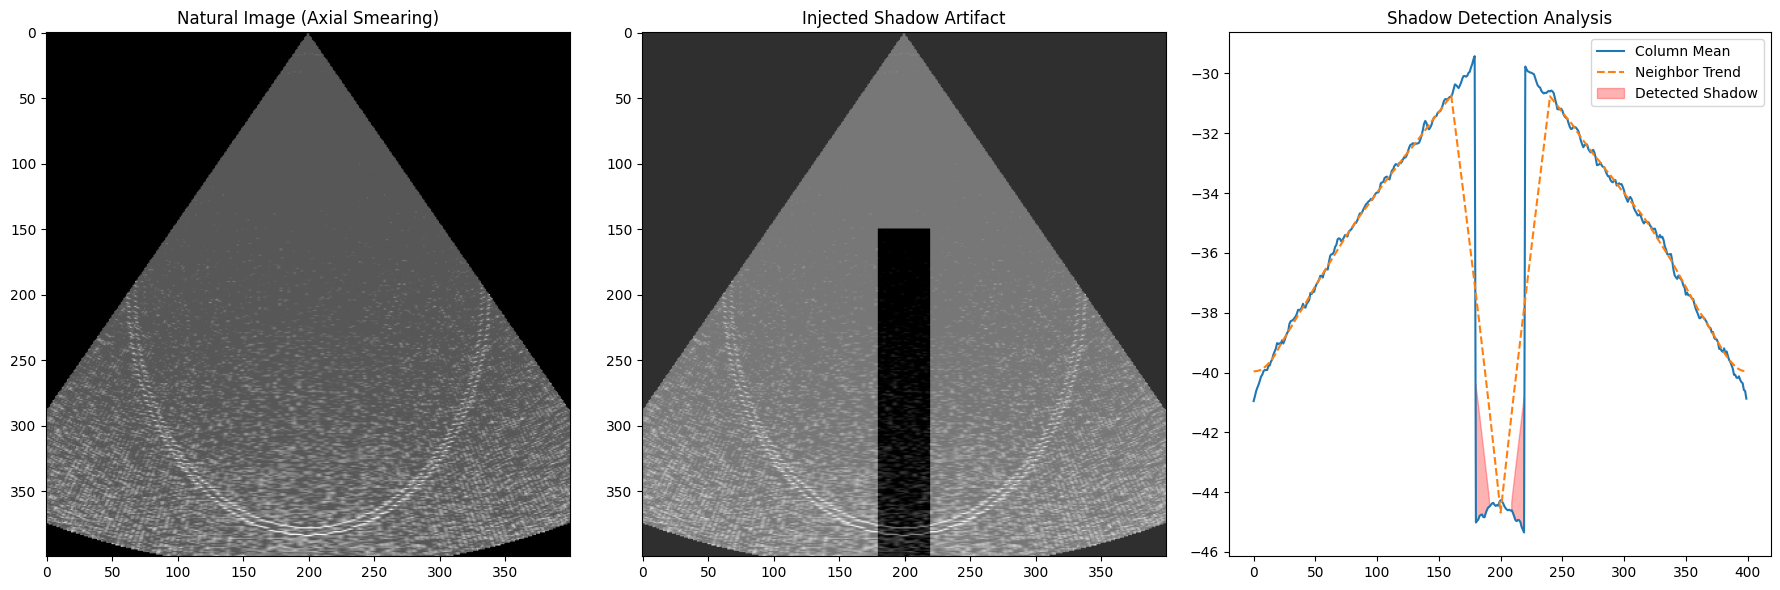

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

# PART A: Analyze Natural Artifacts
# TODO: Load your reconstructed B-mode image from Exercise 3 or 4
# ...

image = bmode_recon


# TODO: Identify and characterize artifacts present in your image
# ...

# Identified: Axial Smearing (due to pulse length) and Specular Dropout (missing vertical edges)
# Characterization: Vertical blurring reduces axial detail; missing edges occur due to angle dependence.

# TODO: Quantify artifact properties (speckle statistics, artifact extent, etc.)
# ...

roi = image[20:50, 190:210] 
roi_linear = 10**(roi / 20)
snr_speckle = np.mean(roi_linear) / (np.std(roi_linear) + 0.01)

print(f"Speckle SNR: {snr_speckle:.2f}")

# PART B: Inject Your Choice of Artifact
# TODO: Choose one artifact type (shadowing, enhancement, reverberation, or other)
# ...

artifact_type = "Shadowing"

# TODO: Synthetically inject the artifact onto your reconstructed image
# ...

shadowed_image = image.copy()
shadow_mask = np.zeros_like(image)
shadow_mask[150:, 180:220] = -25
shadowed_image += shadow_mask

# TODO: Implement a detector for your chosen artifact
# ...

column_intensity = np.mean(shadowed_image, axis=0)
smooth_intensity = uniform_filter(column_intensity, size=40)
detection_threshold = smooth_intensity - 3
detected_shadows = np.where(column_intensity < detection_threshold)[0]

# TODO: Test detector performance and implement mitigation
# ...

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Natural Image (Axial Smearing)")
axes[1].imshow(shadowed_image, cmap='gray')
axes[1].set_title("Injected Shadow Artifact")
axes[2].plot(column_intensity, label="Column Mean")
axes[2].plot(smooth_intensity, '--', label="Neighbor Trend")
axes[2].fill_between(np.arange(len(column_intensity)), detection_threshold, column_intensity, 
                     where=(column_intensity < detection_threshold), color='red', alpha=0.3, label="Detected Shadow")
axes[2].set_title("Shadow Detection Analysis")
axes[2].legend()
plt.tight_layout()
plt.show()

## 4.3 Clinical Artifact Case Studies

### **Questions 13**

You observe a dark (anechoic) structure within the gallbladder at 5 cm depth with a bright acoustic shadow extending below it.
- a) Is this definitely a gallstone? Explain the physical basis of the shadow.
- b) Could it be a polyp instead? What would distinguish them on ultrasound?

### **Answers for Q13**

a) Not necessarily. A typical stone should be hyperechoic with a posterior dark shadow. If the structure is dark and the area behind it is bright, it does not fit the criteria for a stone. The physical basis of shadowing is that when sound waves hit a high reflector or absorber, most energy is blocked. As a result, sound waves cannot penetrate the object, creating a dark zone behind it with no echo signals.

b) It could be a polyp, but polyps usually do not produce shadows. There are two main ways to distinguish them: First is mobility—by changing the patient's position, stones will move with gravity while polyps remain fixed to the gallbladder wall. Second is shadowing, stones typically produce a clean posterior dark shadow, whereas polyps generally do not.

### **Questions 14**

You observe a round, dark (anechoic) mass at 8 cm depth with a bright region immediately behind it.
- a) Is this definitely a cyst? Could it be a hypoechoic solid tumor instead?
- b) Explain the physics of acoustic enhancement behind fluid-filled structures.

### **Answers for Q14**
a) Not necessarily. Although an anechoic appearance with posterior enhancement is a classic feature of a cyst, certain highly uniform solid tumors can also allow sound waves to pass through easily with minimal energy loss, thereby creating a similar enhancement effect behind them.

b) Fluids have much lower attenuation of sound waves than the surrounding soft tissue. When sound waves pass through fluid, they retain more energy compared to waves traveling through the same depth of tissue. When these stronger waves strike the tissue behind the fluid, the reflected signals are stronger. Because the ultrasound machine applies uniform TGC, the area behind the fluid appears brighter than the surrounding regions.

---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable3.ipynb` and `.pdf`

**Due:** Monday, March 16, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Coding Exercises Due |
|---------|--------------------------------|
| **Part 1: Acoustic Physics & Tissue Interactions** | Q1 (a,b,c), Q2 (a,b,c,d), Coding Exercise 1, Q3 (a,b), Q4 (a,b,c) |
| **Part 2: Transducers & Beam Forming** | Q5 (a,b,c,d), Q6 (a,b,c), Coding Exercise 2, Q7 (a,b,c,d) |
| **Part 3: Image Formation & Reconstruction** | Q8 (a,b,c,d), Q9 (a,b,c,d), Coding Exercise 3, Coding Exercise 4 + Analysis, Q10 (a,b,c,d) |
| **Part 4: Doppler Imaging & Artifact Analysis** | Q11 (a,b,c,d), Q12 (a,b,c), Coding Exercise 5, Q13 (a,b), Q14 (a,b) |
